In [3]:
import pypsa
import pandas as pd

INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, lines, links, loads, stores, sub_networks


{'nodes': {'Bus': <matplotlib.collections.PatchCollection at 0x1fa5d972f90>},
 'branches': {'Link': <matplotlib.collections.LineCollection at 0x1fa5d973cb0>,
  'Line': <matplotlib.collections.LineCollection at 0x1fa5dab1450>},
 'flows': {}}

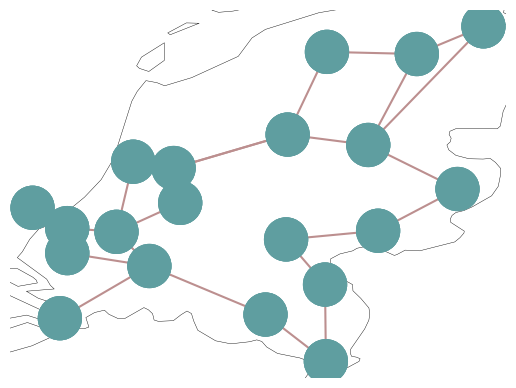

In [4]:
n = pypsa.Network("../external/pypsa-eur/resources/nl20/networks/base_s_20_elec.nc")
n.plot()

In [13]:
n.buses.to_csv("nl20_buses.csv")
# delete H2 and battery buses
n.buses = n.buses[~n.buses.index.isin(n.buses[n.buses.carrier == "H2"].index) & ~n.buses.index.isin(n.buses[n.buses.carrier == "battery"].index)]
n.lines.to_csv("nl20_lines.csv")
# delete generators with zero capacity
n.generators = n.generators[n.generators.p_nom > 0]
n.generators.to_csv("nl20_generators.csv")

In [14]:
print(n.loads.shape)
print(n.loads_t.p_set.shape)

print(n.generators.shape)
print(n.generators_t.p_max_pu.shape)

print(n.generators.carrier.unique())

(20, 7)
(8760, 20)
(81, 42)
(8760, 94)
['CCGT' 'biomass' 'coal' 'waste' 'nuclear' 'offwind-ac' 'solar' 'onwind']


In [7]:
# map each load to its bus
load_to_bus = n.loads["bus"]

# load time series for each load component
load_ts = n.loads_t.p_set.copy()

# aggregate from loads to buses
load_per_bus = load_ts.T.groupby(load_to_bus).sum().T

load_per_bus.to_csv("nl20_load_timeseries_per_bus.csv")

print(load_per_bus.shape)
load_per_bus.head()

(8760, 20)


bus,NL0 0,NL0 1,NL0 10,NL0 11,NL0 12,NL0 13,NL0 14,NL0 15,NL0 16,NL0 17,NL0 18,NL0 19,NL0 2,NL0 3,NL0 4,NL0 5,NL0 6,NL0 7,NL0 8,NL0 9
snapshot,,,,,,,,,,,,,,,,,,,,
2013-01-01 00:00:00,721.880814,563.071976,363.851158,345.225960,655.293144,633.312424,333.819229,558.444000,278.373344,533.591141,660.634796,117.232887,286.896240,283.186996,1005.177338,721.722000,775.122482,287.543884,704.243286,771.376892
2013-01-01 01:00:00,684.492828,533.909096,345.006416,327.345863,621.353905,600.511620,316.529907,529.520821,263.955711,505.955147,626.418900,111.161110,272.037178,268.520050,953.116737,684.342247,734.976982,272.651283,667.768799,731.425392
2013-01-01 02:00:00,648.262589,505.649254,326.745209,310.019424,588.465607,568.726509,299.775963,501.493248,249.984520,479.174919,593.262512,105.277351,257.638237,254.307266,902.668221,648.119972,696.074615,258.219833,632.423752,692.711006
2013-01-01 03:00:00,625.720840,488.066544,315.383438,299.239258,568.003151,548.950432,289.351982,484.055046,241.291916,462.512779,572.633255,101.616585,248.679497,245.464348,871.280128,625.583183,671.870316,249.240868,610.432755,668.623672
2013-01-01 04:00:00,621.430420,484.719978,313.220924,297.187439,564.108482,545.186401,287.367966,480.735992,239.637428,459.341431,568.706841,100.919823,246.974358,243.781258,865.305962,621.293701,667.263458,247.531883,606.247162,664.039070


In [8]:
# aggregate load time series
total_load = load_ts.sum(axis=1)
total_load = total_load.rename("load")
total_load.to_csv("nl20_total_load_timeseries.csv")

In [9]:
renewable_carriers = ['offwind-ac', 'solar', 'onwind']
renewable_generators = n.generators.index[
    n.generators["carrier"].isin(renewable_carriers)
]
cf_ts = n.generators_t.p_max_pu[renewable_generators]
cf_ts.to_csv("nl20_renewable_cf_per_generator.csv")

cf_ts.head()

name,NL0 1 0 offwind-ac,NL0 18 0 offwind-ac,NL0 19 0 offwind-ac,NL0 5 0 offwind-ac,NL0 7 0 offwind-ac,NL0 0 0 solar,NL0 1 0 solar,NL0 10 0 solar,NL0 11 0 solar,NL0 12 0 solar,...,NL0 18 0 onwind,NL0 19 0 onwind,NL0 2 0 onwind,NL0 3 0 onwind,NL0 4 0 onwind,NL0 5 0 onwind,NL0 6 0 onwind,NL0 7 0 onwind,NL0 8 0 onwind,NL0 9 0 onwind
snapshot,,,,,,,,,,,,,,,,,,,,,
2013-01-01 00:00:00,0.885500,0.885500,0.885500,0.885500,0.885500,0.0,0.0,0.0,0.0,0.0,...,0.997914,0.998368,0.997306,0.998188,0.998208,0.998900,0.997908,0.998771,0.998704,0.998459
2013-01-01 01:00:00,0.885500,0.885500,0.885500,0.885500,0.885500,0.0,0.0,0.0,0.0,0.0,...,0.985301,0.993986,0.995982,0.994219,0.986898,0.997506,0.997825,0.993345,0.995430,0.997837
2013-01-01 02:00:00,0.885500,0.885500,0.885500,0.885500,0.885500,0.0,0.0,0.0,0.0,0.0,...,0.920035,0.977576,0.991349,0.980909,0.933149,0.976075,0.996266,0.971971,0.982861,0.994970
2013-01-01 03:00:00,0.884127,0.872605,0.885500,0.885500,0.885500,0.0,0.0,0.0,0.0,0.0,...,0.679465,0.890816,0.970676,0.908642,0.721033,0.870814,0.983264,0.867129,0.898075,0.957570
2013-01-01 04:00:00,0.844524,0.543190,0.666418,0.864808,0.678924,0.0,0.0,0.0,0.0,0.0,...,0.403805,0.686214,0.882081,0.739386,0.437665,0.711187,0.934801,0.614573,0.763964,0.861407


In [10]:
# seperate renewables from controllable generators and exclude project sites with zero capacity
r = n.generators["carrier"].isin(renewable_carriers)

renewable_gens = n.generators[r]
renewable_gens = renewable_gens[renewable_gens["p_nom"] > 0]
controllable_gens = n.generators[~r]

renewable_gens.to_csv("nl20_renewable_generators_raw.csv")
controllable_gens.to_csv("nl20_controllable_generators_raw.csv")

# clean csv files by removing unnecessary columns
cols_to_keep = ["bus", "p_nom", "carrier", "marginal_cost"]
renewable_gens[cols_to_keep].to_csv("nl20_renewable_generators.csv", index=True)
controllable_gens[cols_to_keep].to_csv("nl20_controllable_generators.csv", index=True)
n.generators[cols_to_keep].to_csv("nl20_generators.csv", index=True)




In [11]:
# validation checks that installed capacity per technology matches real life data
cap_onwind = n.generators.loc[n.generators["carrier"] == "onwind", "p_nom"].sum() #wind onshore
print(f"Total installed onshore wind capacity: {cap_onwind:.2f} MW")

cap_offwind_ac = n.generators.loc[n.generators["carrier"] == "offwind-ac", "p_nom"].sum() #wind offshore ac
print(f"Total installed offshore wind (AC) capacity: {cap_offwind_ac:.2f} MW")

cap_solar = n.generators.loc[n.generators["carrier"] == "solar", "p_nom"].sum() #solar
print(f"Total installed solar capacity: {cap_solar:.2f} MW")

cap_ccgt = n.generators.loc[n.generators["carrier"] == "CCGT", "p_nom"].sum() #combined cycle gas turbine
print(f"Total installed combined cycle gas turbine capacity: {cap_ccgt:.2f} MW")

cap_coal = n.generators.loc[n.generators["carrier"] == "coal", "p_nom"].sum() #coal
print(f"Total installed coal capacity: {cap_coal:.2f} MW")

cap_biomass = n.generators.loc[n.generators["carrier"] == "biomass", "p_nom"].sum() #biomass
print(f"Total installed biomass capacity: {cap_biomass:.2f} MW")

cap_nuclear = n.generators.loc[n.generators["carrier"] == "nuclear", "p_nom"].sum() #nuclear
print(f"Total installed nuclear capacity: {cap_nuclear:.2f} MW")

cap_waste = n.generators.loc[n.generators["carrier"] == "waste", "p_nom"].sum() #waste
print(f"Total installed waste capacity: {cap_waste:.2f} MW")


cap_controllable = controllable_gens["p_nom"].sum()
print(f"Total installed controllable capacity: {cap_controllable:.2f} MW")

Total installed onshore wind capacity: 4352.30 MW
Total installed offshore wind (AC) capacity: 7121.00 MW
Total installed solar capacity: 7092.80 MW
Total installed combined cycle gas turbine capacity: 14198.50 MW
Total installed coal capacity: 4706.00 MW
Total installed biomass capacity: 877.00 MW
Total installed nuclear capacity: 515.00 MW
Total installed waste capacity: 696.20 MW
Total installed controllable capacity: 20992.70 MW


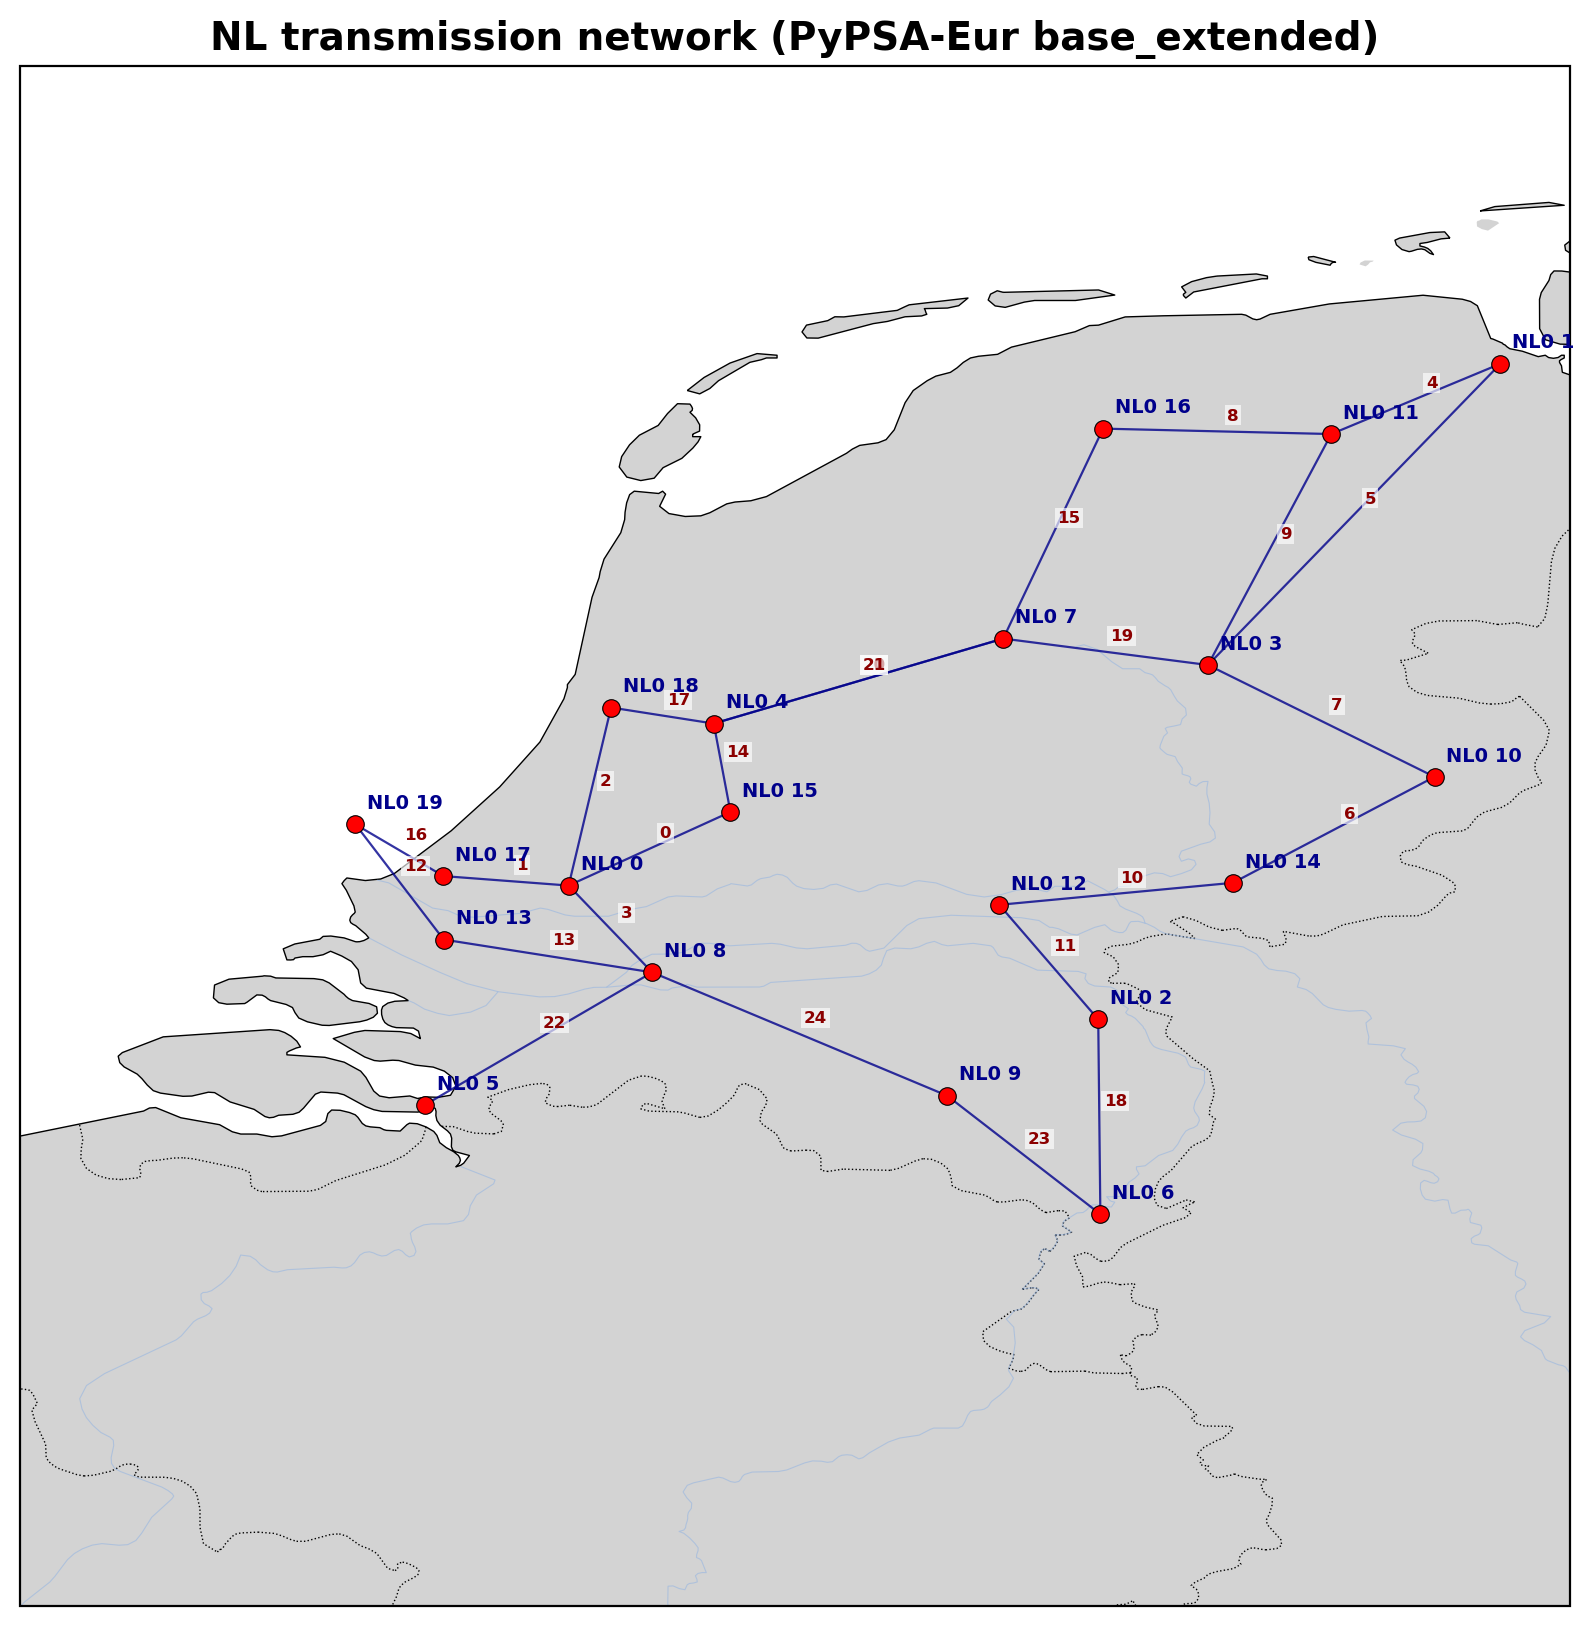

In [27]:
import numpy as np
import matplotlib.pyplot as plt

b = n.buses

# no cross-border lines
nl_buses = b.index[b.country == "NL"]
lines_nl = n.lines.index[n.lines.bus0.isin(nl_buses) & n.lines.bus1.isin(nl_buses)]

import cartopy.crs as ccrs
import cartopy.feature as cfeature

fig, ax = plt.subplots(figsize=(10, 10), dpi=200, subplot_kw=dict(projection=ccrs.PlateCarree()))

# Netherlands background
ax.add_feature(cfeature.LAND.with_scale('10m'), facecolor='lightgray')
ax.add_feature(cfeature.COASTLINE.with_scale('10m'), linewidth=0.5)
ax.add_feature(cfeature.BORDERS.with_scale('10m'), linestyle=':', linewidth=0.5)
ax.add_feature(cfeature.RIVERS.with_scale('10m'), linewidth=0.4, alpha=0.6)

# NL extent (lon_min, lon_max, lat_min, lat_max) - tighter zoom to avoid Belgium
ax.set_extent([3.2, 7.1, 50.8, 53.4], crs=ccrs.PlateCarree())

# draw lines and name labels
for l in lines_nl:
    bus0 = n.lines.at[l, "bus0"]
    bus1 = n.lines.at[l, "bus1"]
    x0, y0 = n.buses.at[bus0, "x"], n.buses.at[bus0, "y"]
    x1, y1 = n.buses.at[bus1, "x"], n.buses.at[bus1, "y"]
    ax.plot([x0, x1], [y0, y1], color='darkblue', linewidth=0.8, alpha=0.8, transform=ccrs.PlateCarree())
    xm, ym = (x0 + x1) / 2, (y0 + y1) / 2
    label_dx, label_dy = 0.04, 0.04
    ax.text(xm + label_dx, ym + label_dy, l, fontsize=6, fontweight='bold', color='darkred',
            transform=ccrs.PlateCarree(), ha='center', va='center', zorder=6,
            bbox=dict(facecolor='white', edgecolor='none', alpha=0.65, pad=0.9))

# draw buses and names
ax.scatter(n.buses.loc[nl_buses, "x"], n.buses.loc[nl_buses, "y"], s=40, color='red', edgecolor='k', linewidth=0.4, transform=ccrs.PlateCarree(), zorder=5)
for bus in nl_buses:
    x, y = n.buses.at[bus, "x"], n.buses.at[bus, "y"]
    # offset labels slightly to reduce overlap with markers
    dx, dy = 0.03, 0.03
    ax.text(x + dx, y + dy, bus, fontsize=7, fontweight='bold', color='darkblue', transform=ccrs.PlateCarree(), ha='left', va='bottom', zorder=6)

ax.set_title("NL transmission network (PyPSA-Eur base_extended)", fontsize=14, fontweight='bold')
ax.set_aspect('equal', adjustable='datalim')
plt.show()

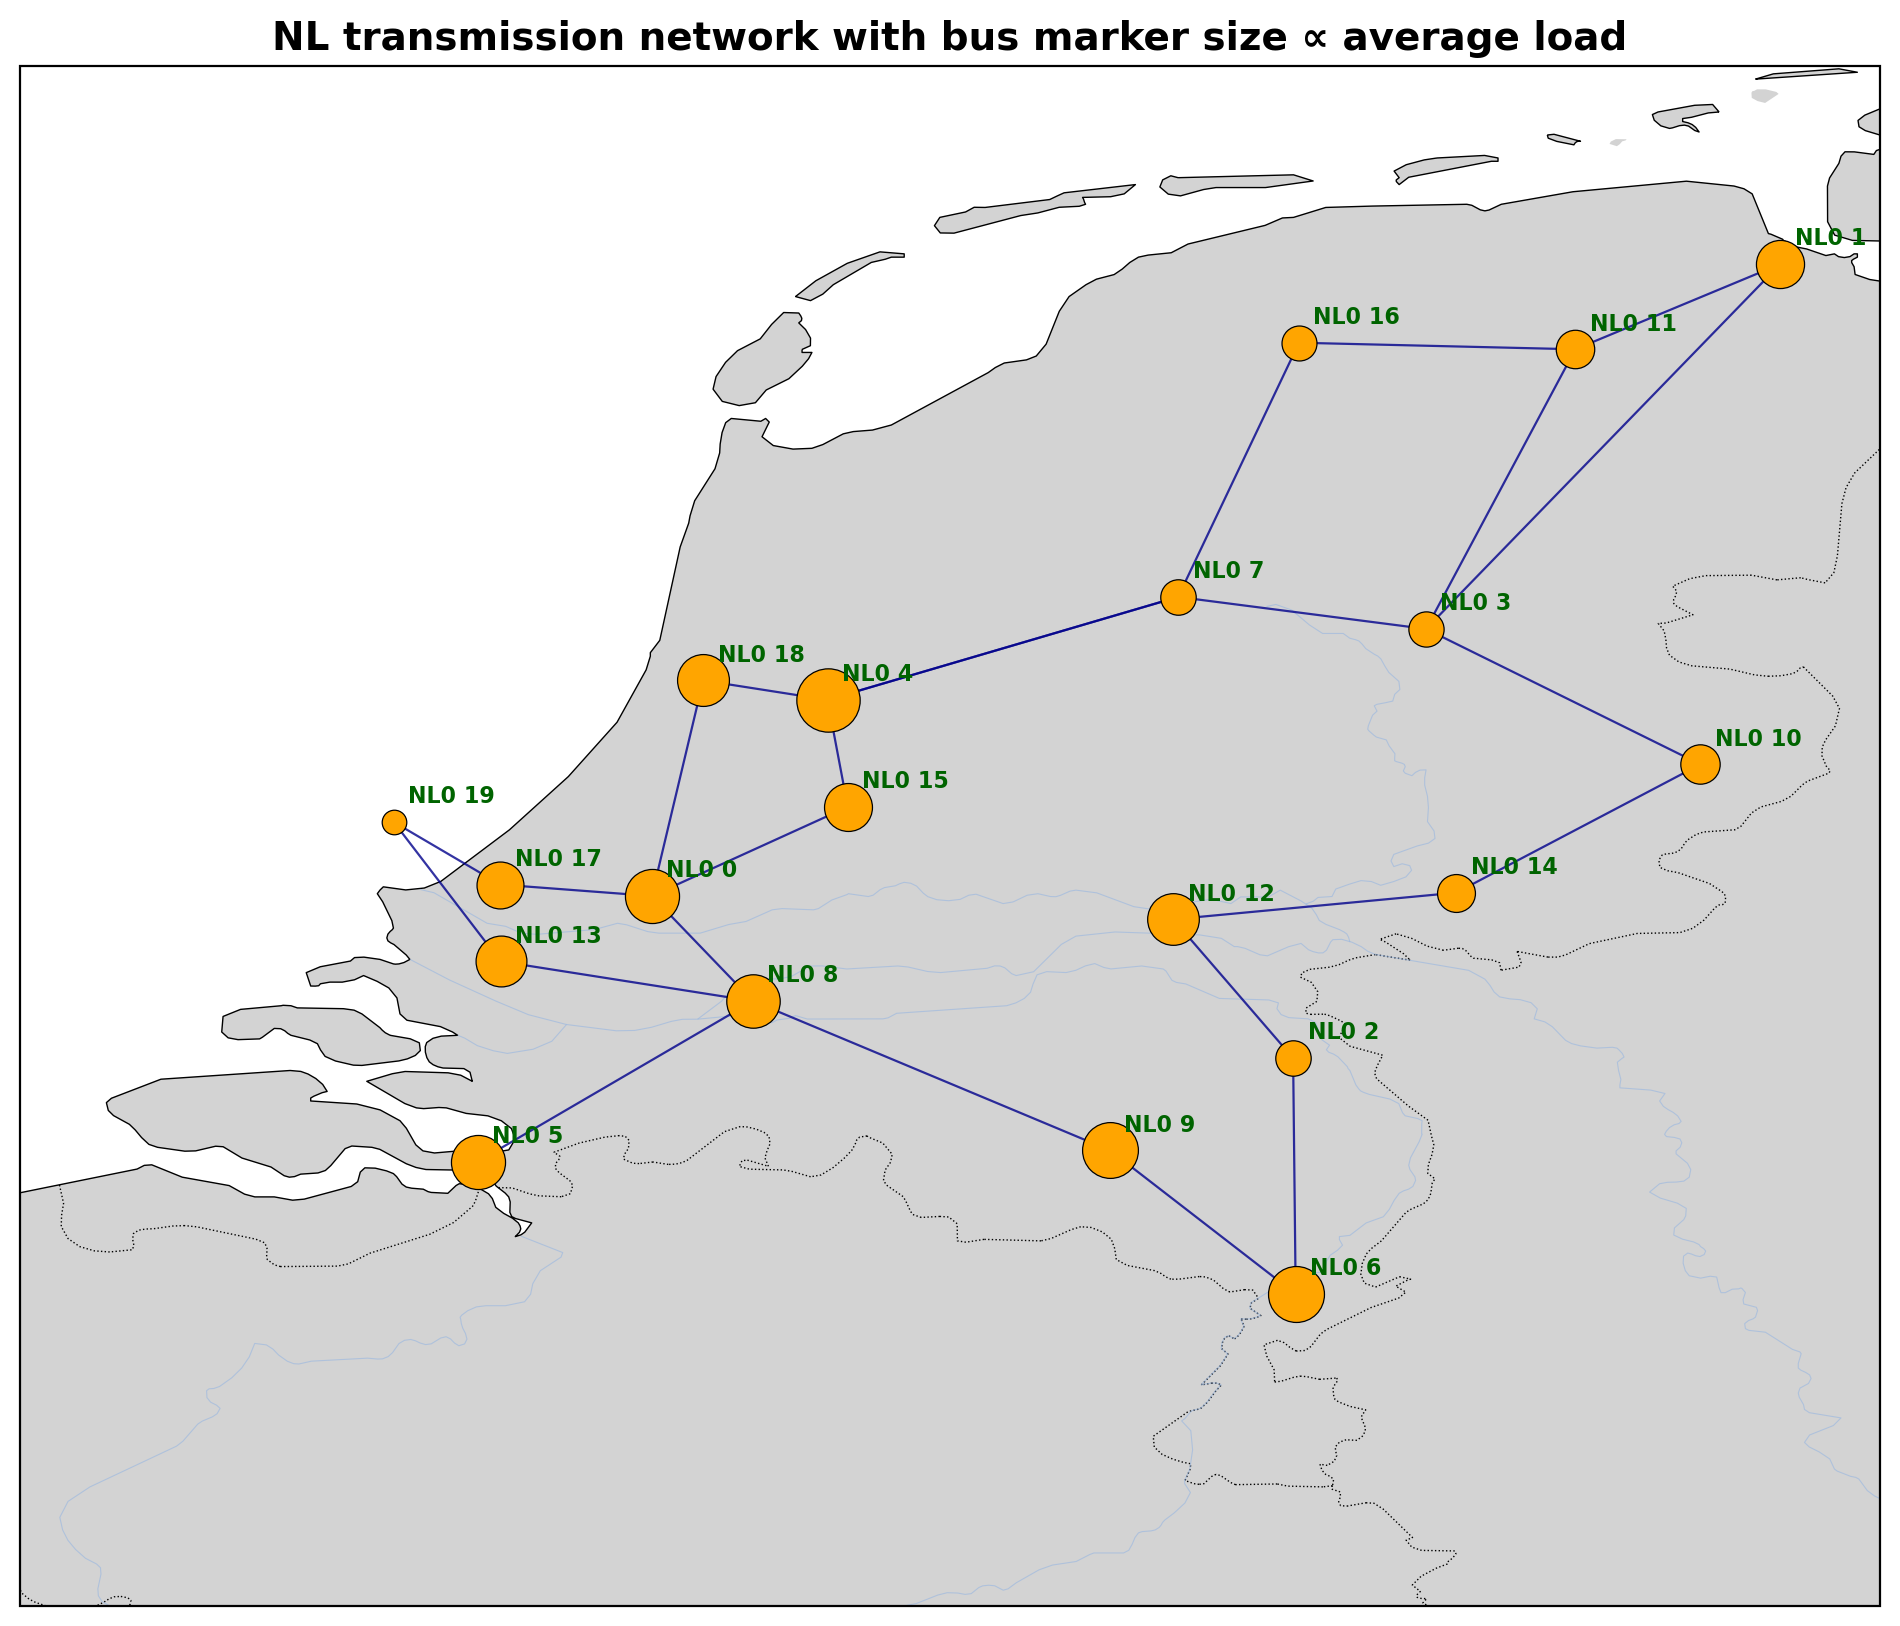

In [28]:
# New map: bus marker size proportional to peak load at each bus
fig, ax = plt.subplots(figsize=(12, 10), dpi=200, subplot_kw=dict(projection=ccrs.PlateCarree()))
ax.add_feature(cfeature.LAND.with_scale('10m'), facecolor='lightgray')
ax.add_feature(cfeature.COASTLINE.with_scale('10m'), linewidth=0.5)
ax.add_feature(cfeature.BORDERS.with_scale('10m'), linestyle=':', linewidth=0.5)
ax.add_feature(cfeature.RIVERS.with_scale('10m'), linewidth=0.4, alpha=0.6)
ax.set_extent([3.0, 7.4, 50.5, 53.7], crs=ccrs.PlateCarree())

# draw lines (same as before)
for l in lines_nl:
    bus0 = n.lines.at[l, "bus0"]
    bus1 = n.lines.at[l, "bus1"]
    x0, y0 = n.buses.at[bus0, "x"], n.buses.at[bus0, "y"]
    x1, y1 = n.buses.at[bus1, "x"], n.buses.at[bus1, "y"]
    ax.plot([x0, x1], [y0, y1], color='darkblue', linewidth=0.8, alpha=0.8, transform=ccrs.PlateCarree())

# compute average load per bus from load_per_bus time series
load = load_per_bus.mean(axis=0) if 'load_per_bus' in globals() else n.loads.groupby('bus')['p_set'].mean()
load_norm = (load / load.max()) * 500

# draw proportional bus markers
for bus in nl_buses:
    x, y = n.buses.at[bus, "x"], n.buses.at[bus, "y"]
    size = load_norm.get(bus, 20) + 20
    ax.scatter(x, y, s=size, color='orange', edgecolor='black', linewidth=0.45, transform=ccrs.PlateCarree(), zorder=6)
    ax.text(x + 0.03, y + 0.03, bus, fontsize=8, fontweight='bold', color='darkgreen', transform=ccrs.PlateCarree(), ha='left', va='bottom', zorder=7)

ax.set_title("NL transmission network with bus marker size ∝ average load", fontsize=14, fontweight='bold')
ax.set_aspect('equal', adjustable='datalim')
plt.show()